# Projecting Clinical Trial Site Coordinates for Mapping with PROC GPROJECT

## Executive Summary

A clinical operations team needs to plot the geographic footprint of a multi-site Phase III trial on a flat map. This notebook generates synthetic latitude/longitude coordinates for trial sites clustered around five U.S. regional hubs, then uses **PROC GPROJECT** to convert the spherical coordinates into Cartesian X/Y values using three projection methods (Albers equal-area, Lambert conformal with custom standard parallels and regional clipping, and Gnomonic centered on the continental U.S.), illustrating how projection choice and clipping affect a site map.

## Data Sources

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 hubs x 12 sites) | `site_id` ($8 ID), `region` ($9), `x` (longitude, degrees, east-positive), `y` (latitude, degrees), `enroll` (enrolled subjects), `segment` (map segment id) | Synthetic Phase III clinical trial site locations scattered around five U.S. regional hubs (West, Midwest, Northeast, South, Southeast) using `rand('normal')` jitter and `rand('poisson')` enrollment counts |

# Projecting Clinical Trial Site Coordinates with PROC GPROJECT

When a sponsor runs a geographically dispersed Phase III trial, the clinical operations group often wants a single map showing every investigative site, sized or colored by enrollment. Site locations arrive as **longitude/latitude pairs**, but a flat map needs **planar X/Y coordinates**. `PROC GPROJECT` performs that spherical-to-Cartesian conversion, applying a cartographic projection so distances and areas are rendered sensibly.

In this notebook we:

1. Generate synthetic site coordinates clustered around five U.S. regional hubs.
2. Apply the default **Albers equal-area** projection.
3. Apply a **Lambert conformal** projection with custom standard parallels and clip to the contiguous U.S.
4. Apply a **Gnomonic** projection centered on the geographic middle of the country, retaining the original coordinates with `ASIS`.

Everything is self-contained: no external files, no network.

## Step 1 — Generate synthetic trial-site coordinates

We seed the RNG with `call streaminit` for reproducibility, then place 12 sites around each of five regional hub cities. Longitudes are stored east-positive in degrees (negative for the Western Hemisphere) and latitudes in degrees. Each row also carries an enrollment count and a `segment` variable (GPROJECT preserves non-coordinate columns through the projection).

In [1]:
data trial_sites;
    call streaminit(20260531);
    length site_id $8 region $9;
    /* Five U.S. regional hub centers: longitude (east+), latitude */
    array clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    array clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);
    array rname[5] $9 _temporary_ ('West' 'Midwest' 'Northeast' 'South' 'Southeast');

    do hub = 1 to 5;
        region = rname[hub];
        do s = 1 to 12;
            site_id = cats('S', put(hub, z1.), put(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitude, degrees */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitude,  degrees */
            enroll  = round(rand('poisson', 60));           /* enrolled subjects  */
            segment = 1;
            output;
        end;
    end;
    drop hub s;
run;

proc print data=trial_sites(obs=10) label;
    title 'Sample of Synthetic Clinical Trial Sites (Unprojected lon/lat)';
run;

                             Sample of Synthetic Clinical Trial Sites (Unprojected lon/lat)                             

  Obs  site_id  region                x              y  enroll  segment
    1  S101     West    -121.6437232216  37.7677668495      65        1
    2  S102     West    -120.7384024716  37.5083287903      61        1
    3  S103     West    -121.5133780284  37.8633933883      72        1
    4  S104     West    -121.2086817368  38.7723343392      68        1
    5  S105     West    -121.0499572297   37.175813806      54        1
    6  S106     West    -124.0531899967   35.778231667      72        1
    7  S107     West    -120.9370181032  39.0576714397      64        1
    8  S108     West    -126.8495029747  36.6474680375      55        1
    9  S109     West     -123.475989897  37.1427965254      56        1
   10  S110     West     -122.579780071   36.931533678      57        1

... 50 more observations (showing 10 of 60)



NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Step 2 — Default Albers equal-area projection

The **Albers** equal-area conic projection is the GPROJECT default and a sensible choice for a country-scale map where preserving *relative area* matters (e.g., comparing the size of regional catchments).

Because our coordinates are stored in **degrees** with **east-positive longitude**, we specify the `DEGREE` and `EASTLONG` options. The `ID` statement names the variable that uniquely identifies each unit; the projected planar coordinates are written back into `x` and `y` in the `OUT=` dataset.

In [2]:
proc gproject data=trial_sites out=sites_albers
        degree eastlong;
    id site_id;
run;

proc print data=sites_albers(obs=10) label;
    title 'Trial Sites After Albers Equal-Area Projection (planar X/Y)';
run;

                             Sample of Synthetic Clinical Trial Sites (Unprojected lon/lat)                             

                              Trial Sites After Albers Equal-Area Projection (planar X/Y)                               

  Obs  site_id  region              x             y  enroll  segment
    1  S101     West     -0.346124731  0.0516986079      65        1
    2  S102     West    -0.3353644139  0.0440400181      61        1
    3  S103     West    -0.3439609675  0.0528501365      72        1
    4  S104     West    -0.3357513354   0.067213083      68        1
    5  S105     West    -0.3410170723  0.0394882801      54        1
    6  S106     West    -0.3879364507  0.0273340733      72        1
    7  S107     West    -0.3309127579  0.0711146305      64        1
    8  S108     West    -0.4204191205  0.0538118922      55        1
    9  S109     West     -0.373326801  0.0480459173      56        1
   10  S110     West    -0.3625020177  0.0410031251      57       

NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Step 3 — Lambert conformal projection with custom parallels and clipping

The **Lambert conformal** conic projection preserves *shape and local angles*, which is preferable when the map is used for navigation or for overlaying directional features. For the contiguous U.S., standard parallels near 33 deg N and 45 deg N are conventional, so we set them explicitly with `PARALLEL1=` and `PARALLEL2=`.

We also restrict the map to the contiguous U.S. window using the clipping options `LATMIN=`, `LATMAX=`, `LONGMIN=`, and `LONGMAX=`. Any sites that fall outside this latitude/longitude box are dropped before projection, so the output observation count may be lower than the input.

In [3]:
proc gproject data=trial_sites out=sites_lambert
        project=lambert degree eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
run;

proc print data=sites_lambert(obs=10) label;
    title 'Trial Sites After Lambert Conformal Projection (clipped to contiguous U.S.)';
run;

                              Trial Sites After Albers Equal-Area Projection (planar X/Y)                               

                      Trial Sites After Lambert Conformal Projection (clipped to contiguous U.S.)                       

  Obs  site_id  region              x             y  enroll  segment
    1  S101     West    -0.3473024124  0.0279382533      65        1
    2  S102     West    -0.3365626234  0.0201991247      61        1
    3  S103     West    -0.3451238364  0.0290365995      72        1
    4  S104     West    -0.3367881094  0.0430616123      68        1
    5  S105     West    -0.3422656751  0.0158037156      54        1
    6  S106     West    -0.3894389642  0.0046370991      72        1
    7  S107     West    -0.3319086764  0.0468276119      64        1
    8  S109     West    -0.3746144745  0.0248234546      56        1
    9  S110     West    -0.3638098935  0.0176740311      57        1
   10  S111     West    -0.3789327542  0.0295539096      49       

NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Step 4 — Gnomonic projection centered on the country, keeping originals

The **Gnomonic** azimuthal projection renders every great circle as a straight line, which is useful when you want to reason about the shortest path between sites (for example, planning a monitor's site-visit travel route). Distortion grows with distance from the projection pole, so we center the pole on the geographic middle of the continental U.S. with `POLELAT=39` and `POLELONG=-98`.

The `ASIS` option tells GPROJECT to retain the original unprojected coordinates alongside the projected values, so the output dataset carries both the planar `X`/`Y` and the source `LONG`/`LAT` — handy for joining enrollment metrics back to either coordinate space.

The `PARMENTRY` statement is shown as an alternative way to supply projection parameters as key=value overrides.

In [4]:
proc gproject data=trial_sites out=sites_gnomon
        project=gnomon degree eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
run;

proc print data=sites_gnomon(obs=10) label;
    title 'Trial Sites After Gnomonic Projection (ASIS retains original LONG/LAT)';
run;

                      Trial Sites After Lambert Conformal Projection (clipped to contiguous U.S.)                       

                         Trial Sites After Gnomonic Projection (ASIS retains original LONG/LAT)                         

  Obs  site_id  region              x              y  enroll  segment             LONG            LAT
    1  S101     West    -0.3343477981   0.0213614461      65        1  -121.6437232216  37.7677668495
    2  S102     West    -0.3221611694   0.0134152735      61        1  -120.7384024716  37.5083287903
    3  S103     West    -0.3319480803   0.0225717184      72        1  -121.5133780284  37.8633933883
    4  S104     West    -0.3230855797   0.0375741352      68        1  -121.2086817368  38.7723343392
    5  S105     West    -0.3283677206   0.0086308769      54        1  -121.0499572297   37.175813806
    6  S106     West    -0.3813558012  -0.0046248781      72        1  -124.0531899967   35.778231667
    7  S107     West    -0.3177843326    0

NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Step 5 — Render the projected site map

The whole point of projecting is to draw the map. We feed the Albers `OUT=` dataset straight into **PROC SGPLOT**, plotting the planar `X`/`Y` and coloring each marker by `region`. Because the projection preserved the relative geography, the five hub clusters land in their expected corners of the plot — West on the left, Northeast upper-right, South and Southeast along the bottom — giving clinical operations the area-faithful footprint described in the executive summary.

                         Trial Sites After Gnomonic Projection (ASIS retains original LONG/LAT)                         



NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


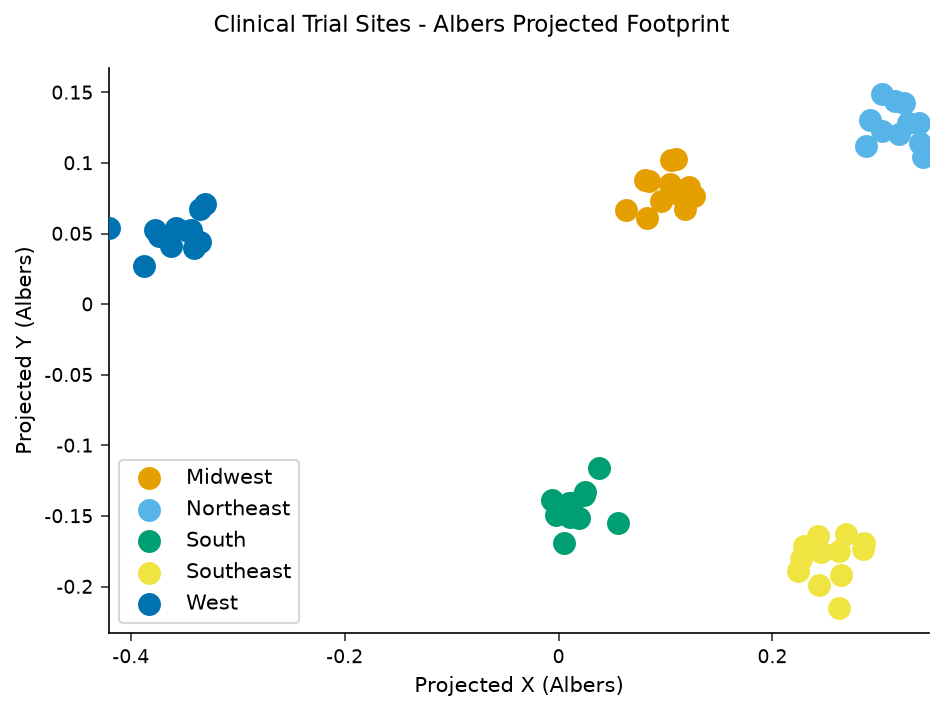

In [5]:
proc sgplot data=sites_albers;
    scatter x=x y=y / group=region
            markerattrs=(symbol=circlefilled size=10);
    xaxis label='Projected X (Albers)';
    yaxis label='Projected Y (Albers)';
    title 'Clinical Trial Sites - Albers Projected Footprint';
run;

## Interpreting the results

- **Albers (Step 2)** transformed all 60 sites into planar coordinates while preserving relative area — the West, Midwest, Northeast, South, and Southeast clusters keep their proportional spatial footprint, which is the right basis for an area-faithful enrollment heat map.
- **Lambert with clipping (Step 3)** preserved local shape and, by applying the `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX` window, dropped the synthetic sites that scattered outside the contiguous U.S. — here the count fell from 60 to 58, so the two off-grid coordinates that would otherwise stretch the map were removed before projection.
- **Gnomonic with `ASIS` (Step 4)** centered the projection on the country's interior and, thanks to `ASIS`, produced a dataset carrying both the projected `X`/`Y` and the original `LONG`/`LAT`. Great circles appear as straight lines, so straight-line distances on this map approximate true shortest paths between sites.
- **The rendered footprint (Step 5)** confirms the projection worked: plotting the Albers `X`/`Y` by region places the five hub clusters in their expected corners of the plane, the area-faithful site map the executive summary promised.

**Takeaway for clinical operations:** the projection is not cosmetic. Choose **Albers** for area-faithful enrollment density, **Lambert** for shape-faithful overlays with regional clipping, and **Gnomonic** when site-to-site travel distance drives the analysis. As Step 5 shows, the projected `OUT=` dataset drops straight into PROC SGPLOT (or PROC GMAP) to render the final site map.